### RaschPy bivector MFRM worked example

This notebook works through a sample Rasch analysis of a simulated data set (200 persons, 8 items with a maximum score of 5, all rated by 8 raters, no missing data), taking you through the relevant commands step by step, with notes before each cell. Relevant outputs will appear below each cell.

Under the bivector parameterisation, each rater's severity is an additive combination of a per-item leniency effect and a per-threshold consistency effect, allowing rater behaviour to vary systematically across the latent continuum without the full item x threshold flexibility (and parameter cost) of the matrix model. It functions as rater-as-RSM, as opposed to the matrix formulation, which functions as rater-as-PCM.

Import the modules and set the working directory (here called `my_working_directory`) to where you want to save your output files.

In [1]:
import raschpy as rp
import os

os.chdir('my_working_directory')

**A note on data validation**

Every model constructor validates the item-response network automatically at instantiation (`validate=True` by default) and warns if it's disconnected — if there's no chain of persons and items linking every item to every other, the resulting item locations aren't on a common scale, even though `calibrate()` will still run without error. This is worth seeing happen once. Here we build a small, deliberately disconnected data set: two groups of persons who each only answer a disjoint set of items, with no item shared between the groups to link them:

In [2]:
sim_disconnected = rp.MFRM_Sim_Bivector(no_of_items=8, no_of_persons=40, no_of_raters=4, max_score=5, seed=99)
responses_disconnected = sim_disconnected.responses.copy()
persons = responses_disconnected.index.get_level_values(1).unique()
group_a, group_b = persons[:20], persons[20:]
responses_disconnected.loc[(slice(None), group_a), responses_disconnected.columns[4:]] = float('nan')   # group A: only items 1-4
responses_disconnected.loc[(slice(None), group_b), responses_disconnected.columns[:4]] = float('nan')    # group B: only items 5-8

broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning

/Users/markelliott/Documents/GitHub/RaschPy/raschpy/mfrm.py:341: UserWarning: The data is split into 2 disconnected sub-networks. This will break un-smoothed calibrations. Isolated groupings: Sub-group 1 (size 4): ['Item_1', 'Item_2', 'Item_3', 'Item_4']; Sub-group 2 (size 4): ['Item_5', 'Item_6', 'Item_7', 'Item_8']
  self.connectivity_status = self.check_data_connectivity()
/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_52760/3556847367.py:8: UserWarning: 
⚠️  CRITICAL DATA INTEGRITY WARNING: The response data is disconnected into 2 separate sub-networks.
Item location estimates will be problematic because there are no empirical comparisons spanning across these isolated groups, the item parameter estimates for each independent subset will separately sum to zero. This means items belonging to different subsets cannot be compared or calibrated onto a single scale.
  broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning


`connectivity_status` records the diagnosis, including which items ended up in which isolated sub-group:

In [3]:
broken_mfrm.connectivity_status

{'connected': False,
 'components_count': 2,
 'isolated_items': [],
 'all_sub_groups': [['Item_1', 'Item_2', 'Item_3', 'Item_4'],
  ['Item_5', 'Item_6', 'Item_7', 'Item_8']],
 'directionally_isolated_items': []}

The rest of this notebook uses a single, fully-connected simulated data set, so this warning won't come up again.

Simulate a data set. Passing `seed=42` makes the simulation fully reproducible — rerunning this notebook will always generate the same data set.

In [4]:
sim = rp.MFRM_Sim_Bivector(no_of_items=8, no_of_persons=200, no_of_raters=8, max_score=5, missing=0, seed=42)
sim.responses.to_csv('mfrm_bivector_scores.csv')

If you have your own response data saved to a CSV file instead of simulating it, use `loadup_mfrm_single()` to load and validate it. Demonstrated here by reloading the file we just saved:

In [5]:
data, invalid_responses = rp.loadup_mfrm_single('mfrm_bivector_scores.csv', max_score=5)

Check the data - view the first two lines

In [6]:
data.head(2)

Item_1  Item_2  Item_3  Item_4  Item_5  Item_6  Item_7  \
Rater   Person                                                             
Rater_1 Person_1     2.0     2.0     3.0     1.0     4.0     0.0     0.0   
        Person_2     3.0     5.0     3.0     4.0     3.0     3.0     1.0   

                  Item_8  
Rater   Person            
Rater_1 Person_1     3.0  
        Person_2     3.0

Check for any invalid responses (not usable for estimation purposes and excluded)

In [7]:
invalid_responses

,,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8
Rater,Person,,,,,,,,


Create an MFRM object. Passing the simulation object `sim` directly (rather than the reloaded `data`) attaches the generating parameters under `mfrm.generating`, which lets us check parameter recovery further down. If you're analysing your own data, pass a DataFrame instead (e.g. `rp.MFRM(data)`).

In [8]:
mfrm = rp.MFRM(sim)

Calibrate under the bivector parameterisation (a per-item leniency effect plus a per-threshold consistency effect for each rater). The `%%time` "magic function" returns the time taken to run the cell contents (algorithm run time in this case).

In [9]:
%%time
mfrm.calibrate_bivector()

CPU times: user 8.47 ms, sys: 340 μs, total: 8.81 ms
Wall time: 8.67 ms


Check the item location estimates - view the first two items

In [10]:
mfrm.items.head(2)

Item_1   -0.576448
Item_2   -0.643856
dtype: float64

Since this is simulated data, we know the true generating item locations and can check how closely the calibration recovered them. The helper below plots generating vs. estimated values, with an identity line (dashed dark red) and a fitted regression line (dashed red) — the closer the points hug the identity line, the better the recovery — alongside the Pearson correlation, SD ratio, regression coefficient, and RMSE:

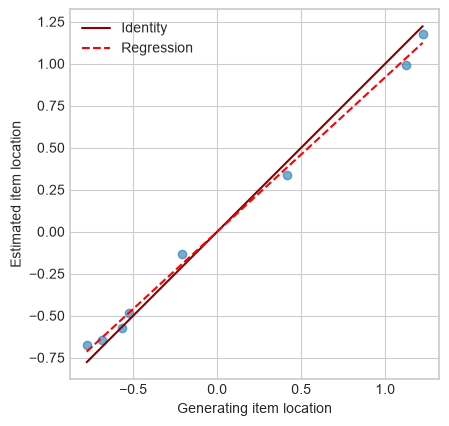

item location Pearson correlation:              0.998
item location SD ratio (estimated / generating): 0.921
item location regression coefficient:            0.919
item location RMSE:                              0.076


In [11]:
import numpy as np
from matplotlib import pyplot as plt

def recovery_plot(generating, estimated, label, filename):
    x, y = np.asarray(generating), np.asarray(estimated)
    fig, ax = plt.subplots()
    ax.scatter(x, y, alpha=0.6)
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], color='DarkRed', label='Identity')
    m, b = np.polyfit(x, y, 1)
    ax.plot([lo, hi], [m * lo + b, m * hi + b], color='Red', linestyle='--', label='Regression')
    ax.set_xlabel(f'Generating {label}')
    ax.set_ylabel(f'Estimated {label}')
    ax.set_aspect('equal')
    ax.legend()
    plt.savefig(filename)
    plt.show()
    print(f'{label} Pearson correlation:              {round(np.corrcoef(x, y)[0, 1], 3)}')
    print(f'{label} SD ratio (estimated / generating): {round(y.std() / x.std(), 3)}')
    print(f'{label} regression coefficient:            {round(m, 3)}')
    print(f'{label} RMSE:                              {round(np.sqrt(((x - y) ** 2).mean()), 3)}')

recovery_plot(sim.items, mfrm.items, 'item location', 'my_mfrm_bivector_item_recovery.png')

Generate a table of item statistics (and check run time), and save to file

In [12]:
%%time
mfrm.item_stats_df_bivector()
mfrm.item_stats_bivector.to_csv('mfrm_bivector_item_stats.csv')

CPU times: user 6.24 s, sys: 95.5 ms, total: 6.33 s
Wall time: 6.34 s


Check the item statistics table - view the first two items

In [13]:
mfrm.item_stats_bivector.head(2)

,Estimate,SE,Count,Facility,Infit MS,Outfit MS
Item_1,-0.576,0.038,1600,0.586,0.870,0.874
Item_2,-0.644,0.036,1600,0.605,0.914,0.920


Generate a table of threshold statistics (and check run time), and save to file

In [14]:
%%time
mfrm.threshold_stats_df_bivector()
mfrm.threshold_stats_bivector.to_csv('mfrm_bivector_threshold_stats.csv')

CPU times: user 58.3 ms, sys: 1.94 ms, total: 60.2 ms
Wall time: 59.8 ms


Check the threshold statistics table - view the first two thresholds

In [15]:
mfrm.threshold_stats_bivector.head(2)

,Estimate,SE,Infit MS,Outfit MS
Threshold 1,-1.926,0.064,0.983,0.981
Threshold 2,-1.282,0.043,0.985,0.972


And the same recovery check for thresholds, against `sim.thresholds`:

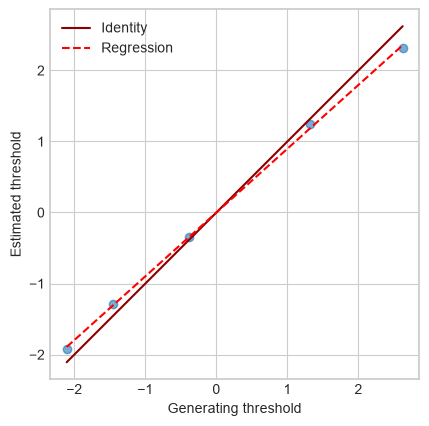

threshold Pearson correlation:              1.0
threshold SD ratio (estimated / generating): 0.898
threshold regression coefficient:            0.898
threshold RMSE:                              0.182


In [16]:
recovery_plot(sim.thresholds, mfrm.thresholds, 'threshold', 'my_mfrm_bivector_threshold_recovery.png')

Generate a table of rater statistics (and check run time), and save to file. `rater_stats_df_bivector` reports per-item marginal severities, then per-threshold marginal severities, plus overall fit statistics for each rater.

In [17]:
%%time
mfrm.rater_stats_df_bivector()
mfrm.rater_stats_bivector.to_csv('mfrm_bivector_rater_stats.csv')

CPU times: user 32.5 ms, sys: 826 μs, total: 33.4 ms
Wall time: 33.3 ms


Check the rater statistics table - view the first rater

In [18]:
mfrm.rater_stats_bivector.head(1).T

Rater_1
Item_1             Estimate      0.521
                   SE            0.113
Item_2             Estimate      0.139
                   SE            0.113
Item_3             Estimate      0.707
                   SE            0.121
Item_4             Estimate      0.567
                   SE            0.122
Item_5             Estimate     -0.875
                   SE            0.117
Item_6             Estimate      0.701
                   SE            0.123
Item_7             Estimate      0.345
                   SE            0.110
Item_8             Estimate      0.117
                   SE            0.112
Threshold 1        Estimate      0.255
                   SE            0.105
Threshold 2        Estimate      0.162
                   SE            0.084
Threshold 3        Estimate      0.067
                   SE            0.078
Threshold 4        Estimate     -0.049
                   SE            0.085
Threshold 5        Estimate     -0.435
                   SE            0.111
Overall statistics Count      1600.000
                   Infit MS      0.943
                   Outfit MS     0.974

The bivector model has two separate rater-effect components — a per-item leniency effect and a per-threshold consistency effect — so there are two recovery checks, against `sim.item_effects` and `sim.threshold_effects` respectively:

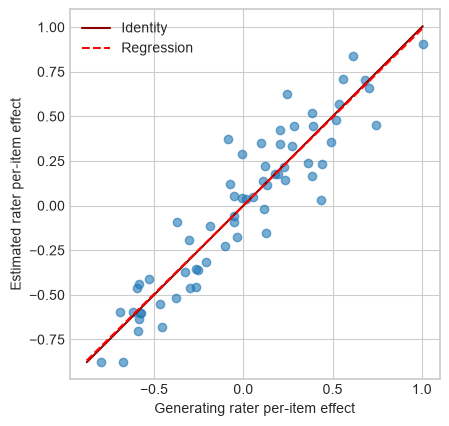

rater per-item effect Pearson correlation:              0.931
rater per-item effect SD ratio (estimated / generating): 1.063
rater per-item effect regression coefficient:            0.989
rater per-item effect RMSE:                              0.162


In [19]:
orig_item_effects = sim.item_effects.stack()
est_item_effects = mfrm.raters_bivector_items.stack()
recovery_plot(orig_item_effects, est_item_effects, 'rater per-item effect', 'my_mfrm_bivector_rater_item_recovery.png')

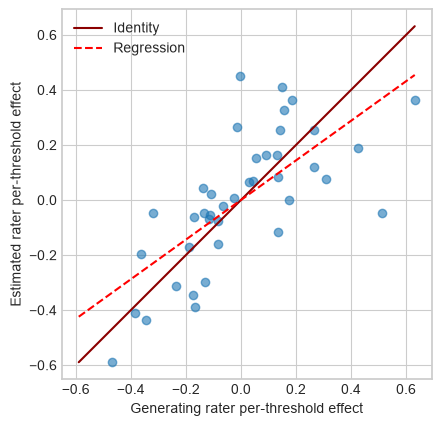

rater per-threshold effect Pearson correlation:              0.705
rater per-threshold effect SD ratio (estimated / generating): 1.02
rater per-threshold effect regression coefficient:            0.719
rater per-threshold effect RMSE:                              0.186


In [20]:
orig_threshold_effects = sim.threshold_effects.stack()
est_threshold_effects = mfrm.raters_bivector_thresholds.stack()
recovery_plot(orig_threshold_effects, est_threshold_effects, 'rater per-threshold effect', 'my_mfrm_bivector_rater_threshold_recovery.png')

Generate a table of person statistics (and check run time), and save to file

In [21]:
%%time
mfrm.person_stats_df_bivector()
mfrm.person_stats_bivector.to_csv('mfrm_bivector_person_stats.csv')

CPU times: user 10.6 ms, sys: 746 μs, total: 11.4 ms
Wall time: 11.3 ms


Check the person statistics table - view the first two persons

In [22]:
mfrm.person_stats_bivector.head(2)

,Estimate,CSEM,Score,Max score,p,Infit MS,Outfit MS
Person_1,-0.300,0.137,149,320,0.466,0.708,0.691
Person_2,1.193,0.149,224,320,0.700,0.910,0.959


And the same recovery check for person locations, against `sim.persons`:

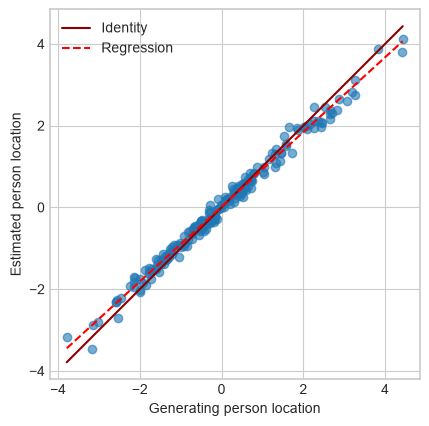

person location Pearson correlation:              0.994
person location SD ratio (estimated / generating): 0.919
person location regression coefficient:            0.914
person location RMSE:                              0.195


In [23]:
recovery_plot(sim.persons, mfrm.persons_bivector, 'person location', 'my_mfrm_bivector_person_recovery.png')

Generate a table of test-level statistics (and check run time), and save to file

In [24]:
%%time
mfrm.test_stats_df_bivector()
mfrm.test_stats_bivector.to_csv('mfrm_bivector_test_stats.csv')

CPU times: user 2.06 ms, sys: 450 μs, total: 2.51 ms
Wall time: 2.45 ms


Check the test statistics table

In [25]:
mfrm.test_stats_bivector

,Items,Persons
Mean,0.000,0.015
SD,0.750,1.391
Separation ratio,19.976,9.609
Strata,26.968,13.146
Reliability,0.998,0.989


Run an item residual correlation analysis (and check run time), and save relevant output to file

In [26]:
%%time
mfrm.item_res_corr_analysis_bivector()
mfrm.item_residual_correlations_bivector.to_csv('mfrm_bivector_item_residual_correlations.csv')
mfrm.item_loadings_bivector.to_csv('mfrm_bivector_item_loadings.csv')

CPU times: user 4.43 ms, sys: 1.57 ms, total: 6 ms
Wall time: 7.47 ms


View the table of pairwise standard residual correlations (pairwise local item independence check)

In [27]:
mfrm.item_residual_correlations_bivector

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8
Item_1,1.000000,-0.007959,-0.017117,0.015544,-0.047813,-0.001268,-0.015428,0.001158
Item_2,-0.007959,1.000000,0.009477,-0.034320,-0.021800,0.017869,0.031108,0.007997
Item_3,-0.017117,0.009477,1.000000,0.002062,-0.033272,-0.019717,-0.004654,-0.026599
Item_4,0.015544,-0.034320,0.002062,1.000000,0.002210,0.028910,-0.019374,-0.006646
Item_5,-0.047813,-0.021800,-0.033272,0.002210,1.000000,-0.003329,-0.007568,0.012467
Item_6,-0.001268,0.017869,-0.019717,0.028910,-0.003329,1.000000,0.062403,-0.050625
Item_7,-0.015428,0.031108,-0.004654,-0.019374,-0.007568,0.062403,1.000000,-0.025896
Item_8,0.001158,0.007997,-0.026599,-0.006646,0.012467,-0.050625,-0.025896,1.000000


View the item loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [28]:
mfrm.item_loadings_bivector['PC 1']

Item_1    0.063661
Item_2   -0.087436
Item_3   -0.014496
Item_4    0.066319
Item_5    0.107348
Item_6   -0.207879
Item_7   -0.208703
Item_8    0.236362
Name: PC 1, dtype: float64

Run a rater residual correlation analysis (and check run time), and save relevant output to file

In [29]:
%%time
mfrm.rater_res_corr_analysis_bivector()
mfrm.rater_residual_correlations_bivector.to_csv('mfrm_bivector_rater_residual_correlations.csv')
mfrm.rater_loadings_bivector.to_csv('mfrm_bivector_rater_loadings.csv')

CPU times: user 7.76 ms, sys: 535 μs, total: 8.3 ms
Wall time: 8.35 ms


View the table of pairwise standard residual correlations (pairwise local rater independence check)

In [30]:
mfrm.rater_residual_correlations_bivector

,Rater_1,Rater_2,Rater_3,Rater_4,Rater_5,Rater_6,Rater_7,Rater_8
Rater_1,1.000000,-0.017912,0.005189,-0.005947,-0.029310,-0.011914,-0.022221,-0.038476
Rater_2,-0.017912,1.000000,-0.023705,0.025153,-0.014602,-0.018914,-0.012739,-0.024417
Rater_3,0.005189,-0.023705,1.000000,0.004097,-0.030967,-0.002665,-0.059026,-0.020707
Rater_4,-0.005947,0.025153,0.004097,1.000000,-0.025072,0.001198,-0.027150,-0.020128
Rater_5,-0.029310,-0.014602,-0.030967,-0.025072,1.000000,0.008149,-0.056450,-0.012974
Rater_6,-0.011914,-0.018914,-0.002665,0.001198,0.008149,1.000000,0.011123,-0.020194
Rater_7,-0.022221,-0.012739,-0.059026,-0.027150,-0.056450,0.011123,1.000000,0.009232
Rater_8,-0.038476,-0.024417,-0.020707,-0.020128,-0.012974,-0.020194,0.009232,1.000000


View the rater loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [31]:
mfrm.rater_loadings_bivector['PC 1']

Rater_1   -0.089804
Rater_2   -0.003496
Rater_3   -0.230761
Rater_4   -0.080100
Rater_5   -0.037217
Rater_6   -0.000177
Rater_7    0.260584
Rater_8    0.168526
Name: PC 1, dtype: float64

Produce an item characteristic curve (item response function) curve for Item 2, with observed category means plotted and the central item location marked

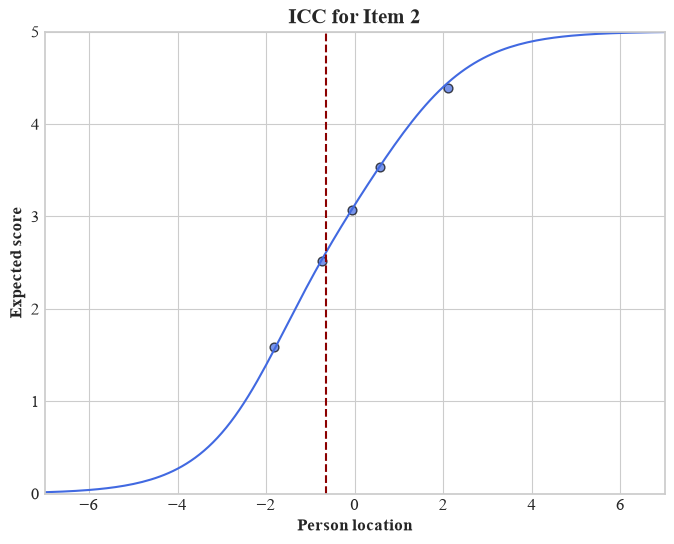

In [32]:
mfrm.icc_bivector('Item_2', title='ICC for Item 2', obs=True, central_location=True, cat_highlight=3, xmin=-7, xmax=7, filename='my_mfrm_bivector_icc')

Produce a set of category response curves for Item 2, with category 1 highlighted and the thresholds marked

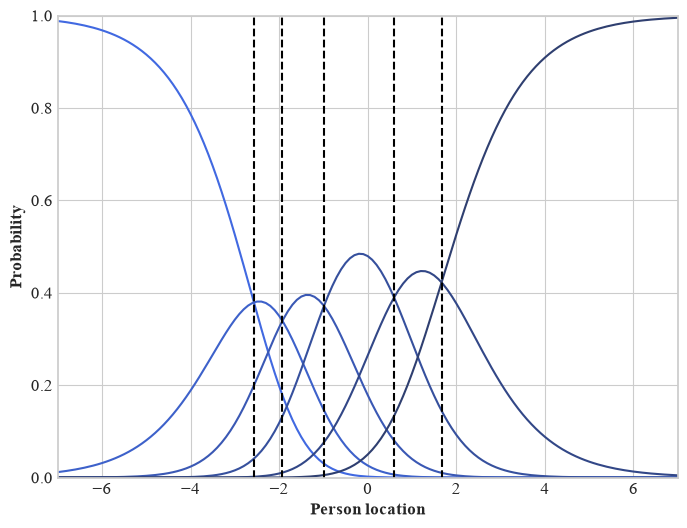

In [33]:
mfrm.crcs_bivector('Item_2', thresh_lines=True, cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_bivector_crcs')

Produce a set of threshold characteristic curves for Item 2, with observed category means plotted for threshold 5, category 1 highlighted and the thresholds marked

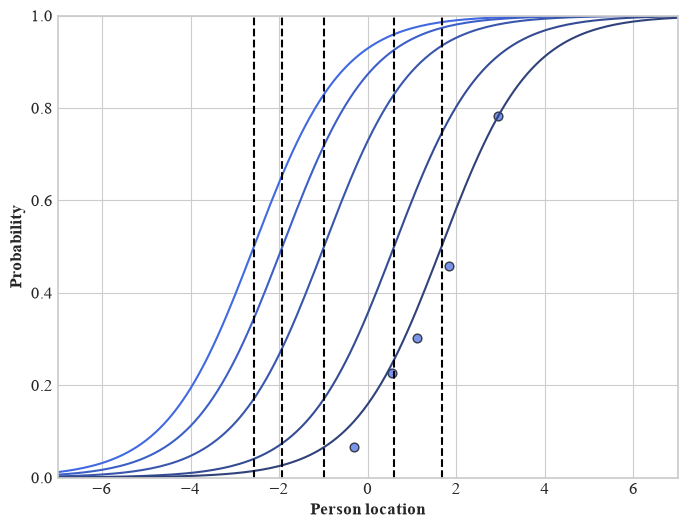

In [34]:
mfrm.threshold_ccs_bivector('Item_2', thresh_lines=True, obs=[5], cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_bivector_threshold_ccs')

Produce an item information function curve for Item 2

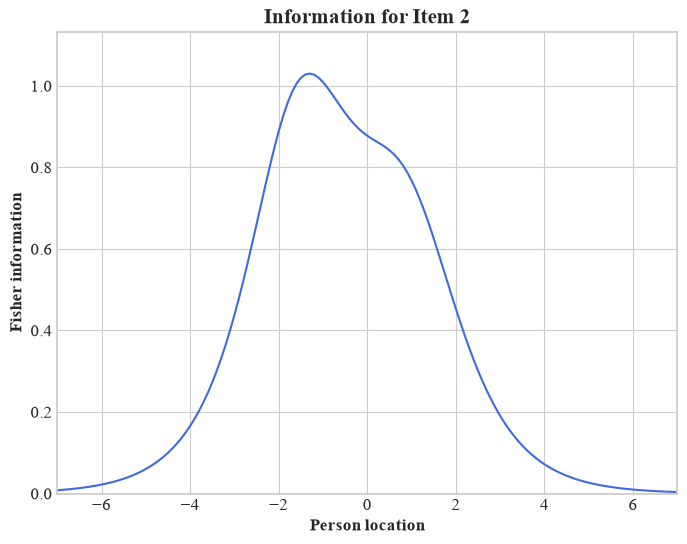

In [35]:
mfrm.iic_bivector('Item_2', title='Information for Item 2', xmin=-7, xmax=7, filename='my_mfrm_bivector_iic')

Produce a test characteristic curve (test response function), with person locations corresponding to scores of 20 and 30 plotted.

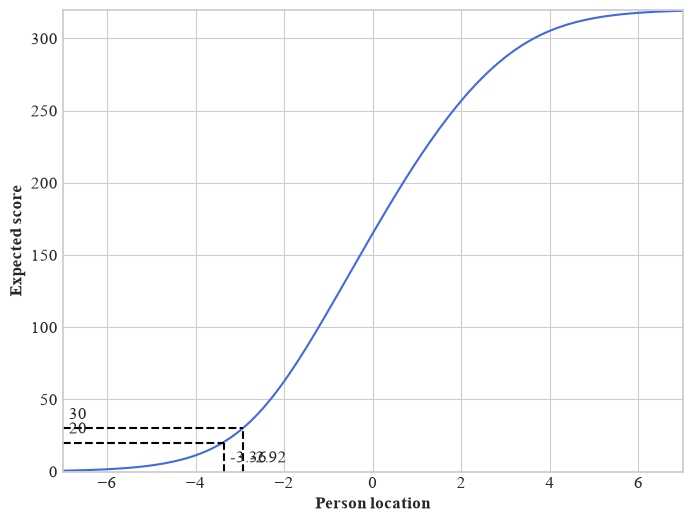

In [36]:
mfrm.tcc_bivector(score_lines=[20, 30], score_labels=True, xmin=-7, xmax=7, filename='my_mfrm_bivector_tcc')

Produce a test information curve

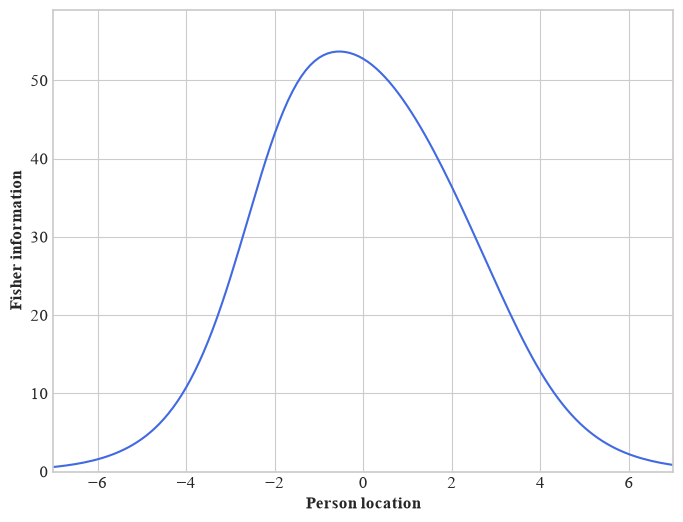

In [37]:
mfrm.test_info_bivector(xmin=-7, xmax=7, filename='my_mfrm_bivector_test_info_curve')

Produce a test CSEM (conditional standard error of measurement) curve, with the CSEM corresponding to a person location of -3 plotted

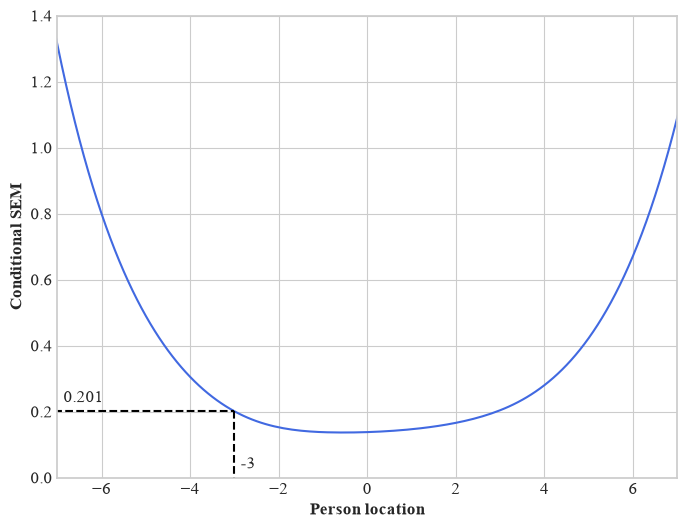

In [38]:
mfrm.test_csem_bivector(point_csem_lines=[-3], point_csem_labels=True, ymax=1.4, xmin=-7, xmax=7, filename='my_mfrm_bivector_csem_curve')

Produce a histogram of standardised residuals, with a normal distribution curve overlaid

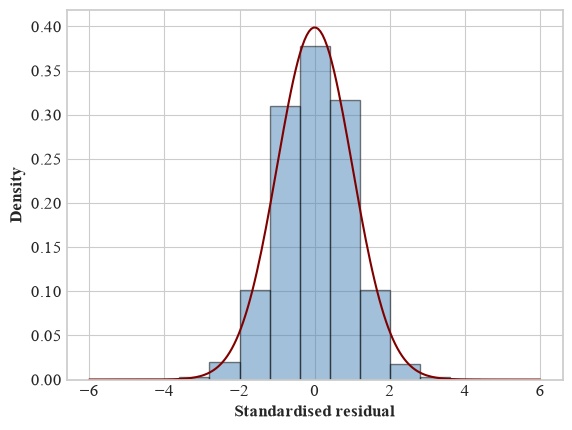

In [39]:
mfrm.std_residuals_plot_bivector(bin_width=0.6, normal=True, filename='my_mfrm_bivector_std_residuals_plot')

Now run an anchored analysis, anchoring to the mean severity of Raters 1-4 (e.g. a set of 'gold standard' raters).

In [40]:
%%time
anchors = ['Rater_1', 'Rater_2', 'Rater_3', 'Rater_4']
mfrm.calibrate_bivector_anchor(anchors)

CPU times: user 6.32 ms, sys: 415 μs, total: 6.74 ms
Wall time: 6.55 ms


Check the anchored item locations against the unanchored ones.

In [41]:
mfrm.items

Item_1   -0.576448
Item_2   -0.643856
Item_3   -0.482325
Item_4    0.336927
Item_5   -0.672193
Item_6    1.177480
Item_7    0.993049
Item_8   -0.132634
dtype: float64

In [42]:
mfrm.anchor_items_bivector

Item_1   -0.573064
Item_2   -0.901249
Item_3   -0.330520
Item_4    0.548555
Item_5   -0.947066
Item_6    1.240789
Item_7    1.046454
Item_8   -0.083899
dtype: float64

Check the anchored thresholds against the unanchored thresholds

In [43]:
mfrm.thresholds

1   -1.925906
2   -1.281936
3   -0.343203
4    1.239756
5    2.311289
dtype: float64

In [44]:
mfrm.anchor_thresholds_bivector

1   -1.789338
2   -1.341522
3   -0.400475
4    1.317756
5    2.213578
dtype: float64

Check the anchored per-item rater effects against the unanchored ones.

In [45]:
mfrm.raters_bivector_items

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8
Rater_1,0.520946,0.138607,0.707133,0.566654,-0.875419,0.701131,0.344726,0.116507
Rater_2,-0.596879,0.220042,-0.111393,0.907657,0.424218,0.217121,-0.357906,-0.597064
Rater_3,0.047442,-0.632433,0.357699,0.233236,0.165302,-0.551742,0.452054,0.241412
Rater_4,0.443498,-0.354315,0.055247,-0.459564,-0.412121,0.288194,0.176219,0.835555
Rater_5,-0.457877,0.038705,-0.056858,-0.318030,-0.436418,-0.463244,-0.600570,-0.091580
Rater_6,-0.223898,0.657205,0.331695,0.041620,0.478864,0.177232,-0.372831,-0.703197
Rater_7,0.144546,-0.514876,-0.682620,-0.877369,0.028695,-0.174014,-0.017617,-0.155047
Rater_8,0.122224,0.447065,-0.600904,-0.094204,0.626879,-0.194677,0.375924,0.353414


In [46]:
mfrm.anchor_raters_bivector_items

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8
Rater_1,0.417194,0.295632,0.454962,0.254658,-0.700914,0.537455,0.190952,-0.032595
Rater_2,-0.700631,0.377067,-0.363564,0.595662,0.598723,0.053445,-0.511679,-0.746167
Rater_3,-0.056310,-0.475408,0.105527,-0.078760,0.339807,-0.715418,0.298281,0.092310
Rater_4,0.339747,-0.197290,-0.196924,-0.771560,-0.237616,0.124518,0.022446,0.686452
Rater_5,-0.561629,0.195730,-0.309030,-0.630025,-0.261913,-0.626920,-0.754343,-0.240683
Rater_6,-0.327650,0.814229,0.079524,-0.270375,0.653370,0.013556,-0.526604,-0.852300
Rater_7,0.040794,-0.357851,-0.934792,-1.189364,0.203201,-0.337689,-0.171390,-0.304149
Rater_8,0.018472,0.604090,-0.853076,-0.406200,0.801385,-0.358353,0.222150,0.204312


Check the anchored per-threshold rater effects against the unanchored ones.

In [47]:
mfrm.raters_bivector_thresholds

,1,2,3,4,5
Rater_1,0.254776,0.162298,0.066986,-0.048654,-0.435405
Rater_2,0.449278,-0.346137,-0.158438,0.077102,-0.021806
Rater_3,-0.410974,-0.054453,-0.060612,0.162354,0.363684
Rater_4,0.253197,-0.000052,-0.077024,0.121197,-0.297318
Rater_5,-0.589338,-0.048878,0.328413,0.264528,0.045274
Rater_6,0.067812,-0.313571,0.084277,0.008511,0.152972
Rater_7,0.021854,0.411846,-0.068160,-0.196385,-0.169156
Rater_8,-0.046604,0.188946,-0.115444,-0.388653,0.361755


In [48]:
mfrm.anchor_raters_bivector_thresholds

,1,2,3,4,5
Rater_1,0.118207,0.221884,0.124258,-0.126654,-0.337694
Rater_2,0.312709,-0.286551,-0.101166,-0.000897,0.075906
Rater_3,-0.547543,0.005133,-0.003340,0.084354,0.461396
Rater_4,0.116628,0.059534,-0.019752,0.043197,-0.199607
Rater_5,-0.725907,0.010708,0.385685,0.186529,0.142985
Rater_6,-0.068757,-0.253986,0.141549,-0.069489,0.250683
Rater_7,-0.114715,0.471432,-0.010888,-0.274384,-0.071445
Rater_8,-0.183173,0.248532,-0.058172,-0.466653,0.459466
